<div style="
    background-color:#E23744;
    padding:0px;
    border-radius:18px;
    text-align:center;
">

<img src="./Zomato logo.png"
     width="20%"
     style="display:block; margin:auto;">

</div>

<div style="
    background-color:#E23744;
    padding:30px;
    border-radius:18px;
    text-align:center;
">

<h1 style="
    color:white;
    font-size:32px;
    font-weight:700;
    margin:0;
    line-height:1.3;
    text-align:center;
">
    Analysis of Zomato's Food Delivery Operations
</h1>

<p style="
    color:white;
    font-size:20px;
    font-weight:500;
    margin:10px 0 0;
    line-height:1.5;
    text-align:center;
    width:100%;
">
    Exploring the Key Factors Influencing Food Delivery Time
</p>

</div>

## Project Description

This project focuses on analyzing Zomato's food delivery operations and understanding the factors associated with delivery time. The dataset contains information related to delivery personnel, restaurants, delivery locations, weather conditions, road traffic, vehicle conditions, order types, festivals, distance, and delivery duration.

The analysis aims to explore the food delivery process and identify how different operational and environmental factors are related to delivery time. Python will be used to examine the dataset and derive meaningful insights from the available information.

## Project Objectives

**The key objectives of this project are:**

- To analyze the overall **delivery time** of food orders.
- To examine the relationship between **road traffic conditions** and delivery time.
- To study how **weather conditions** are associated with delivery time.
- To analyze delivery time across different **types of orders**.
- To examine the relationship between **delivery distance** and delivery time.
- To explore how **delivery locations** are associated with variations in delivery time.
- To identify the key factors that are most closely associated with food delivery time.

## Dataset Overview

The dataset contains 22 columns covering order details, delivery personnel, locations, environmental conditions, vehicle information, and delivery performance.

| Column | Description |
|---|---|
| `ID` | Unique identifier for each order. |
| `Delivery_person_ID` | Identifier of the delivery person. |
| `Delivery_person_Age` | Age of the delivery person. |
| `Delivery_person_Ratings` | Rating received by the delivery person. |
| `Restaurant_latitude` | Latitude of the restaurant location. |
| `Restaurant_longitude` | Longitude of the restaurant location. |
| `Delivery_location_latitude` | Latitude of the delivery location. |
| `Delivery_location_longitude` | Longitude of the delivery location. |
| `Order_Date` | Date on which the order was placed. |
| `Time_Orderd` | Time at which the order was placed. |
| `Time_Order_picked` | Time at which the order was picked up. |
| `Weather_conditions` | Weather condition during the delivery. |
| `Road_traffic_density` | Traffic condition during the delivery. |
| `Vehicle_condition` | Condition of the delivery vehicle. |
| `Type_of_order` | Category of the food order. |
| `Type_of_vehicle` | Type of vehicle used for delivery. |
| `multiple_deliveries` | Number of deliveries handled together. |
| `Festival` | Indicates whether the order was placed during a festival period. |
| `City` | Classification of the delivery location. |
| `Time_taken (min)` | Total time taken to complete the delivery, in minutes. |
| `distance_km` | Distance between the restaurant and delivery location, in kilometres. |
| `delivery_speed` | Categorised delivery speed based on delivery time. |

<div style="
    background-color:#E23744;
    padding:18px;
    border-radius:18px;
    text-align:center;
">

<h2 style="
    color:white;
    font-size:24px;
    font-weight:700;
    margin:0;
    line-height:1.3;
    text-align:center;
">
    Importing Libraries and Warnings
</h2>

</div>

### Import Libraries

The required Python libraries are imported for data manipulation, numerical analysis and analysis with vizualisations.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Import Warnings

The warnings module is imported to manage unnecessary warning messages during the analysis.

In [93]:
import warnings
warnings.filterwarnings('ignore')

<div style="
    background-color:#E23744;
    padding:18px;
    border-radius:18px;
    text-align:center;
">

<h2 style="
    color:white;
    font-size:24px;
    font-weight:700;
    margin:0;
    line-height:1.3;
    text-align:center;
">
    Data Loading and Review
</h2>

</div>

### Load the Dataset

The Zomato food delivery dataset is loaded into a Pandas DataFrame for initial review and further analysis.

In [94]:
df = pd.read_csv("zomato_cleaned.csv")

### Initial Dataset Inspection

The dataset is examined to understand its size, structure, data types, and basic statistical characteristics before proceeding with data preprocessing.

In [95]:
df.shape

# Shows the number of rows and columns.

(38964, 22)

In [96]:
df.columns

# Displays all column names

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)',
       'distance_km', 'delivery_speed'],
      dtype='object')

In [97]:
df.info()

# Shows column names, data types, and non-null counts.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38964 entries, 0 to 38963
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           38964 non-null  object 
 1   Delivery_person_ID           38964 non-null  object 
 2   Delivery_person_Age          37945 non-null  float64
 3   Delivery_person_Ratings      37909 non-null  float64
 4   Restaurant_latitude          38964 non-null  float64
 5   Restaurant_longitude         38964 non-null  float64
 6   Delivery_location_latitude   38964 non-null  float64
 7   Delivery_location_longitude  38964 non-null  float64
 8   Order_Date                   38964 non-null  object 
 9   Time_Orderd                  38129 non-null  object 
 10  Time_Order_picked            38964 non-null  object 
 11  Weather_conditions           38964 non-null  object 
 12  Road_traffic_density         38964 non-null  object 
 13  Vehicle_conditio

In [98]:
df.describe()

# Provides basic statistics for numerical columns.

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min),distance_km
count,37945.000000,37909.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000,38964.000000
mean,29.607089,4.631879,18.915583,76.914536,18.979545,76.978498,0.995534,0.749589,26.581511,9.765092
std,5.763202,0.317006,5.460635,3.498179,5.462504,3.498357,0.817312,0.572172,9.339546,5.605705
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.066047,73.938972,0.000000,0.000000,19.000000,4.658009
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.663067,1.000000,1.000000,26.000000,9.219906
75%,35.000000,4.900000,22.751234,78.368855,22.820072,78.405467,2.000000,1.000000,33.000000,13.681590
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2.000000,3.000000,54.000000,20.969489


In [99]:
df.head()

# Displays the first five rows of the dataset.

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,Average
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,Average
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,Average
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,Slow


In [100]:
df.tail()

# Displays the last five rows of the dataset.

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
38959,0x1178,RANCHIRES16DEL01,35.0,4.2,23.371292,85.327872,23.481292,85.437872,08-03-2022,21:45,...,Jam,2,Drinks,motorcycle,1.0,No,Metropolitian,33,16.600272,Average
38960,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35,...,High,1,Meal,motorcycle,0.0,No,Metropolitian,32,1.489846,Average
38961,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50,...,Low,1,Drinks,scooter,0.0,No,Metropolitian,16,4.657195,Fast
38962,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35,...,High,0,Snack,motorcycle,1.0,No,Metropolitian,26,6.232393,Average
38963,0x5fb2,RANCHIRES09DEL02,23.0,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10,...,Medium,2,Snack,scooter,1.0,No,Metropolitian,36,12.074396,Slow


<div style="
    background-color:#E23744;
    padding:18px;
    border-radius:18px;
    text-align:center;
">

<h2 style="
    color:white;
    font-size:24px;
    font-weight:700;
    margin:0;
    line-height:1.3;
    text-align:center;
">
    Data Cleaning & Preprocessing
</h2>

</div>

####  **I. Check missing values**

Missing values are checked to assess the completeness of the dataset.

In [101]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1019
Delivery_person_Ratings        1055
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                     835
Time_Order_picked                 0
Weather_conditions                0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken (min)                  0
distance_km                       0
delivery_speed                    0
dtype: int64

> **Finding:** Missing values are present in `Delivery_person_Age`, `Delivery_person_Ratings`, and `Time_Orderd`.

In [102]:
df.drop(columns=['Delivery_person_Age'], inplace=True)

> **Finding:** `Delivery_person_Age` was removed because it is not directly relevant to the defined project objectives.

In [103]:
df.drop(columns=['Delivery_person_Ratings'], inplace=True)

> **Finding:** `Delivery_person_Ratings` was removed as it is not required for the defined analysis objectives.

In [104]:
df['Time_Orderd'].value_counts(dropna=False).head(20)

Time_Orderd
NaN            835
17:55          407
21:55          402
19:50          401
21:15          399
18:35          396
19:55          394
0.833333333    388
21:35          385
22:20          384
21:20          384
17:40          383
22:45          381
18:10          381
22:10          377
20:40          376
20:50          376
21:40          376
20:35          375
17:35          375
Name: count, dtype: int64

> **Finding:** `Time_Orderd` contains 835 missing values and inconsistent time representations, including standard time formats and decimal values. The column requires standardization before missing values are handled.

#### **II. Check duplicate records**

Duplicate records are checked to ensure that the same order has not been recorded more than once.

In [105]:
df.duplicated().sum()

np.int64(0)

> **Finding:** No duplicate records were found in the dataset.

#### **III. Check inconsistent categorical values**

Categorical columns are examined for inconsistent values that may affect the accuracy of the analysis.

In [106]:
categorical_columns = [
    'Weather_conditions',
    'Road_traffic_density',
    'Type_of_order',
    'Type_of_vehicle',
    'Festival',
    'City'
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].dropna().unique())


Weather_conditions:
['Fog' 'Stormy' 'Sandstorms' 'Windy' 'Cloudy' 'Sunny']

Road_traffic_density:
['Jam' 'High' 'Medium' 'Low']

Type_of_order:
['Snack' 'Meal' 'Drinks' 'Buffet']

Type_of_vehicle:
['motorcycle' 'scooter' 'electric_scooter']

Festival:
['No' 'Yes']

City:
['Metropolitian' 'Urban' 'Semi-Urban']


##### **Object to datetime**

>The `Order_Date`, `Time_Orderd` and `Time_Order_picked` column is checked and converted from text format to datetime format for accurate date-based analysis.

In [107]:
df[['Order_Date', 'Time_Orderd', 'Time_Order_picked']].dtypes

Order_Date           object
Time_Orderd          object
Time_Order_picked    object
dtype: object

In [108]:
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    format='%d-%m-%Y',
    errors='coerce'
)

In [109]:
df['Order_Date'].isnull().sum(), df['Order_Date'].dtype

(np.int64(0), dtype('<M8[ns]'))

##### **Inconsistency in `Time_Orderd`**
>The `Time_Orderd` column is inspected and standardized to ensure that different time representations are converted into a consistent format.

In [110]:
df['Time_Orderd'].dropna().apply(type).value_counts()

Time_Orderd
<class 'str'>    38129
Name: count, dtype: int64

In [111]:
df['Time_Orderd'].dropna().unique()

array(['21:55', '14:55', '17:30', '09:20', '19:50', '20:25', '20:30',
       '21:15', '20:20', '22:30', '08:15', '19:30', '12:25', '18:35',
       '20:35', '23:20', '21:20', '23:35', '22:35', '23:25', '13:35',
       '18:55', '14:15', '0.458333333', '09:45', '08:40', '0.958333333',
       '17:25', '19:45', '19:10', '10:55', '21:40', '0.791666667',
       '16:45', '11:30', '15:10', '22:45', '20:45', '22:50', '17:55',
       '22:25', '22:40', '23:50', '15:25', '10:20', '20:55', '20:10',
       '12:10', '15:30', '20:50', '12:35', '0.875', '18:15', '18:20',
       '11:45', '12:45', '23:30', '10:50', '21:25', '10:10', '17:50',
       '22:20', '23:40', '12:40', '23:55', '10:25', '08:45', '10:35',
       '23:45', '19:55', '22:15', '23:10', '18:25', '22:10', '18:45',
       '16:50', '1', '21:10', '14:20', '10:15', '08:50', '0.375', '17:45',
       '08:30', '21:45', '14:50', '18:10', '12:30', '17:10', '19:15',
       '20:40', '17:20', '18:30', '21:35', '13:10', '19:35', '09:50',
       '0.83333

> **Finding:** `Time_Orderd` contains both standard time values and decimal representations of time. These values need to be standardized before converting the column to a proper time format.

In [112]:
def convert_time(value):
    if pd.isna(value):
        return value
    
    value = str(value).strip()
    
    if ':' in value:
        return value
    
    decimal_time = float(value)
    
    if decimal_time == 1:
        return '00:00'
    
    total_minutes = round(decimal_time * 24 * 60)
    hours = (total_minutes // 60) % 24
    minutes = total_minutes % 60
    
    return f'{hours:02d}:{minutes:02d}'

df['Time_Orderd'] = df['Time_Orderd'].apply(convert_time)

**Note:**
* Some time values are stored as decimal fractions of a 24-hour day (e.g., 0.5 represents 12:00 and 0.75 represents 18:00).
* This function converts these decimal values into HH:MM format, while retaining existing HH:MM values and leaving missing values unchanged.

In [113]:
df['Time_Orderd'].dropna().unique()

array(['21:55', '14:55', '17:30', '09:20', '19:50', '20:25', '20:30',
       '21:15', '20:20', '22:30', '08:15', '19:30', '12:25', '18:35',
       '20:35', '23:20', '21:20', '23:35', '22:35', '23:25', '13:35',
       '18:55', '14:15', '11:00', '09:45', '08:40', '23:00', '17:25',
       '19:45', '19:10', '10:55', '21:40', '19:00', '16:45', '11:30',
       '15:10', '22:45', '20:45', '22:50', '17:55', '22:25', '22:40',
       '23:50', '15:25', '10:20', '20:55', '20:10', '12:10', '15:30',
       '20:50', '12:35', '21:00', '18:15', '18:20', '11:45', '12:45',
       '23:30', '10:50', '21:25', '10:10', '17:50', '22:20', '23:40',
       '12:40', '23:55', '10:25', '08:45', '10:35', '23:45', '19:55',
       '22:15', '23:10', '18:25', '22:10', '18:45', '16:50', '00:00',
       '21:10', '14:20', '10:15', '08:50', '09:00', '17:45', '08:30',
       '21:45', '14:50', '18:10', '12:30', '17:10', '19:15', '20:40',
       '17:20', '18:30', '21:35', '13:10', '19:35', '09:50', '20:00',
       '12:50', '10:

> **Finding:** The different time representations in `Time_Orderd` have been standardized into a consistent `HH:MM` format.

In [114]:
df['Time_Orderd'] = pd.to_datetime(
    df['Time_Orderd'],
    format='%H:%M',
    errors='coerce'
)

In [115]:
df['Time_Orderd'].dtype

dtype('<M8[ns]')

> **Finding:** `Time_Orderd` was successfully converted to datetime format after standardizing the inconsistent time representations.

In [116]:
df['Time_Order_picked'].dropna().unique()

array(['22:10', '15:05', '17:40', '09:30', '20:05', '20:35', '15:10',
       '20:40', '21:30', '20:25', '22:45', '08:30', '19:45', '12:30',
       '18:50', '23:30', '21:35', '23:45', '22:50', '22:40', '23:35',
       '13:40', '19:10', '14:25', '11:10', '09:55', '08:55', '23:10',
       '17:30', '18:35', '19:50', '19:25', '0.458333333', '21:45',
       '19:15', '16:55', '11:40', '15:15', '22:55', '20:55', '23:05',
       '0.75', '0.958333333', '22:35', '0.916666667', '23:55', '15:40',
       '10:30', '0.875', '20:15', '12:15', '15:45', '24:05:00', '12:45',
       '21:15', '18:20', '18:25', '11:50', '12:50', '10:55', '21:40',
       '10:20', '17:55', '22:25', '23:50', '12:55', '24:10:00', '10:40',
       '0.375', '20:20', '20:45', '10:50', '0.833333333', '23:15',
       '22:20', '21:05', '0.708333333', '24:15:00', '21:20', '14:35',
       '10:25', '09:05', '08:40', '20:50', '23:40', '21:50', '0.625',
       '17:20', '19:30', '17:25', '20:10', '17:35', '1', '0.791666667',
       '19:05', 

In [117]:
def standardize_time(value):
    if pd.isna(value):
        return value

    value = str(value).strip()

    # Handle HH:MM:SS format
    if value.count(':') == 2:
        hours, minutes, seconds = value.split(':')
        hours = int(hours)
        minutes = int(minutes)

        # Convert 24:xx to 00:xx
        if hours == 24:
            hours = 0

        return f'{hours:02d}:{minutes:02d}'

    # Handle HH:MM format
    if ':' in value:
        hours, minutes = value.split(':')
        return f'{int(hours):02d}:{int(minutes):02d}'

    # Handle decimal representation of time
    decimal_time = float(value)

    if decimal_time == 1:
        return '00:00'

    total_minutes = round(decimal_time * 24 * 60)
    hours = (total_minutes // 60) % 24
    minutes = total_minutes % 60

    return f'{hours:02d}:{minutes:02d}'

**Note:**
* The time columns contain values in different formats, including HH:MM, HH:MM:SS, decimal fractions of a 24-hour day, and 24:xx time values.
* This function standardizes these different representations into a consistent HH:MM format before converting the column to datetime.

In [118]:
df['Time_Order_picked'] = df['Time_Order_picked'].apply(standardize_time)

In [119]:
df['Time_Order_picked'].dropna().unique()

array(['22:10', '15:05', '17:40', '09:30', '20:05', '20:35', '15:10',
       '20:40', '21:30', '20:25', '22:45', '08:30', '19:45', '12:30',
       '18:50', '23:30', '21:35', '23:45', '22:50', '22:40', '23:35',
       '13:40', '19:10', '14:25', '11:10', '09:55', '08:55', '23:10',
       '17:30', '18:35', '19:50', '19:25', '11:00', '21:45', '19:15',
       '16:55', '11:40', '15:15', '22:55', '20:55', '23:05', '18:00',
       '23:00', '22:35', '22:00', '23:55', '15:40', '10:30', '21:00',
       '20:15', '12:15', '15:45', '00:05', '12:45', '21:15', '18:20',
       '18:25', '11:50', '12:50', '10:55', '21:40', '10:20', '17:55',
       '22:25', '23:50', '12:55', '00:10', '10:40', '09:00', '20:20',
       '20:45', '10:50', '20:00', '23:15', '22:20', '21:05', '17:00',
       '00:15', '21:20', '14:35', '10:25', '09:05', '08:40', '20:50',
       '23:40', '21:50', '15:00', '17:20', '19:30', '17:25', '20:10',
       '17:35', '00:00', '19:00', '19:05', '13:20', '17:50', '18:05',
       '19:20', '10:

>**Finding:** The `Time_Order_picked` column contained both standard and decimal time representations. These values are standardized into a consistent `HH:MM` format.

In [120]:
df['Time_Order_picked'] = pd.to_datetime(
    df['Time_Order_picked'],
    format='%H:%M',
    errors='coerce'
)

In [121]:
df['Time_Order_picked'].dtype, df['Time_Order_picked'].isnull().sum()

(dtype('<M8[ns]'), np.int64(0))

> **Finding:** `Time_Order_picked` was successfully converted to datetime format after standardizing the inconsistent time representations.

##### **Handling the missing values in `Time_Orderd`**

In [122]:
df[['Time_Orderd', 'Time_Order_picked']].isnull().all(axis=1).sum()

# How many rows have both Time_Orderd and Time_Order_picked are missing

np.int64(0)

In [123]:
df['Time_Orderd'].isnull().sum(), df.loc[df['Time_Orderd'].isnull(), 'Time_Order_picked'].notnull().sum()

# How many have a missing Time_Orderd but have a known pickup time

(np.int64(835), np.int64(835))

In [124]:
df.drop(columns=['Time_Orderd'], inplace=True)

> **Finding:** `Time_Orderd` was removed due to 835 missing values and its limited relevance to the defined project objectives. `Time_Order_picked` was retained as a complete time-related variable for supplementary analysis.

##### **Handling inconsistent categorical**

In [125]:
df['Type_of_vehicle'] = df['Type_of_vehicle'].replace({
    'motorcycle': 'Motorcycle',
    'scooter': 'Scooter',
    'electric_scooter': 'Electric scooter'
})

df['City'] = df['City'].replace({
    'Metropolitian': 'Metropolitan'
})

In [126]:
for column in ['Type_of_vehicle', 'City']:
    print(f"\n{column}:")
    print(df[column].unique())


Type_of_vehicle:
['Motorcycle' 'Scooter' 'Electric scooter']

City:
['Metropolitan' 'Urban' 'Semi-Urban']


> **Finding:** Inconsistent categorical formatting and a spelling variation in the city category were identified and standardized to ensure consistent grouping during analysis.

#### **IV. Checking and handling unnecessary columns**

The dataset is reviewed for columns that are not required for the defined analysis objectives or may introduce redundancy into the analysis.

In [127]:
df.drop(columns=[
    'ID',
    'Delivery_person_ID'
], inplace=True)

In [128]:
df.columns

Index(['Restaurant_latitude', 'Restaurant_longitude',
       'Delivery_location_latitude', 'Delivery_location_longitude',
       'Order_Date', 'Time_Order_picked', 'Weather_conditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'Time_taken (min)', 'distance_km', 'delivery_speed'],
      dtype='object')

> **Finding:** Identifier columns that do not contribute to the analysis were removed. Variables that may support the defined objectives were retained for further evaluation.

#### **V. Detect Outliers Using IQR**

The Interquartile Range (IQR) method is used to identify unusually high or low values in relevant numerical variables. Outliers are examined before deciding whether any values require treatment.

In [129]:
numeric_columns = [
    'Time_taken (min)',
    'distance_km',
    'multiple_deliveries'
]

df[numeric_columns].describe()

,Time_taken (min),distance_km,multiple_deliveries
count,38964.000000,38964.000000,38964.000000
mean,26.581511,9.765092,0.749589
std,9.339546,5.605705,0.572172
min,10.000000,1.465067,0.000000
25%,19.000000,4.658009,0.000000
50%,26.000000,9.219906,1.000000
75%,33.000000,13.681590,1.000000
max,54.000000,20.969489,3.000000


In [130]:
numeric_columns = [
    'Time_taken (min)',
    'distance_km',
    'multiple_deliveries'
]

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f'\n{column}')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Lower Bound: {lower_bound}')
    print(f'Upper Bound: {upper_bound}')
    print(f'Potential Outliers: {len(outliers)}')


Time_taken (min)
Q1: 19.0
Q3: 33.0
IQR: 14.0
Lower Bound: -2.0
Upper Bound: 54.0
Potential Outliers: 0

distance_km
Q1: 4.658009301231346
Q3: 13.681590426854768
IQR: 9.023581125623423
Lower Bound: -8.877362387203789
Upper Bound: 27.216962115289903
Potential Outliers: 0

multiple_deliveries
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Bound: -1.5
Upper Bound: 2.5
Potential Outliers: 313


> **Finding:** The IQR analysis identified no potential outliers in `Time_taken (min)` or `distance_km`. However, 313 potential outliers were detected in `multiple_deliveries`. These observations will be examined further before deciding whether any treatment is required.

In [131]:
df['multiple_deliveries'].value_counts().sort_index()

multiple_deliveries
0.0    12165
1.0    24704
2.0     1782
3.0      313
Name: count, dtype: int64

> **Finding:** The 313 observations with `multiple_deliveries = 3` were identified as IQR-based outliers. However, the value represents a valid number of simultaneous deliveries and is not a data-quality error. Therefore, these observations were retained for further analysis.

#### **VI. Feature engineering**

Relevant features are derived from the existing variables to support the analysis objectives and make the data easier to analyze.

In [132]:
df['Pickup_Hour'] = df['Time_Order_picked'].dt.hour

In [133]:
df[['Time_Order_picked', 'Pickup_Hour']].head()

,Time_Order_picked,Pickup_Hour
0,1900-01-01 22:10:00,22
1,1900-01-01 15:05:00,15
2,1900-01-01 17:40:00,17
3,1900-01-01 09:30:00,9
4,1900-01-01 20:05:00,20


**Note:** 

`Pickup_Hour` is created from `Time_Order_picked` to represent the hour of the day when an order was picked up. This makes it easier to examine whether delivery time varies across different periods of the day.

#### **VII. Quality check**

In [134]:
df.isnull().sum()

Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
distance_km                    0
delivery_speed                 0
Pickup_Hour                    0
dtype: int64

In [135]:
df.dtypes

Restaurant_latitude                   float64
Restaurant_longitude                  float64
Delivery_location_latitude            float64
Delivery_location_longitude           float64
Order_Date                     datetime64[ns]
Time_Order_picked              datetime64[ns]
Weather_conditions                     object
Road_traffic_density                   object
Vehicle_condition                       int64
Type_of_order                          object
Type_of_vehicle                        object
multiple_deliveries                   float64
Festival                               object
City                                   object
Time_taken (min)                        int64
distance_km                           float64
delivery_speed                         object
Pickup_Hour                             int32
dtype: object

In [136]:
df.shape

(38964, 18)

**Exporting the refined dataset**

The final cleaned dataset contains **38,964 records and 18 variables** with no missing values, and is ready for exploratory data analysis and visualization.

In [137]:
df.to_csv("Zomato_Cleaned_Dataset.csv",index=False)

<div style="
    background-color:#E23744;
    padding:18px;
    border-radius:18px;
    text-align:center;
">

<h2 style="
    color:white;
    font-size:24px;
    font-weight:700;
    margin:0;
    line-height:1.3;
    text-align:center;
">
    Exploratory Data Analysis (EDA)
</h2>

</div>

### Overall Delivery Time Analysis

The overall delivery time is examined using descriptive statistics to understand the typical delivery duration and the spread of delivery times across all orders.

In [138]:
df['Time_taken (min)'].describe()

count    38964.000000
mean        26.581511
std          9.339546
min         10.000000
25%         19.000000
50%         26.000000
75%         33.000000
max         54.000000
Name: Time_taken (min), dtype: float64

> **Finding:** The average delivery time is **26.58 minutes**, while the median is **26 minutes**, indicating that a typical order takes around 26 minutes to be delivered. Delivery times range from **10 to 54 minutes**, with 50% of orders falling between **19 and 33 minutes**.

#### 1. **How Are Delivery Times Distributed?**

The distribution of delivery time is examined to understand how frequently different delivery durations occur across the orders.

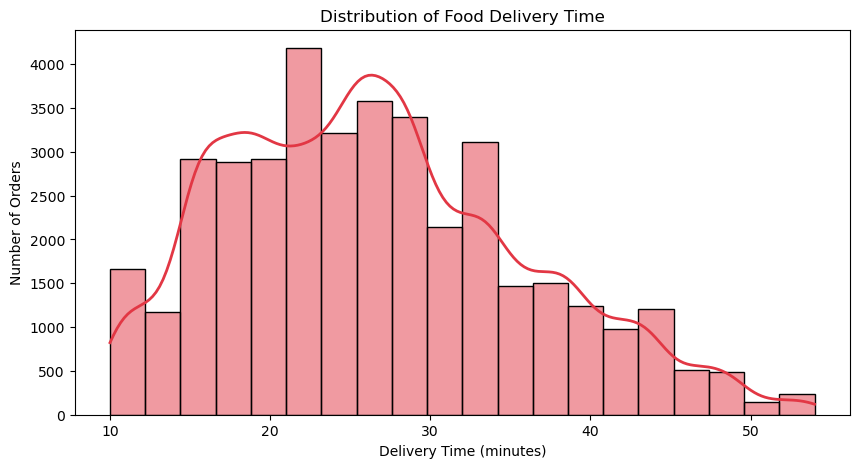

In [139]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Time_taken (min)',
    bins=20,
    kde=True,
    color='#E23744',
    line_kws={'color': '#FFD700', 'linewidth': 2}
)

plt.title('Distribution of Food Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Number of Orders')
plt.show()

#### **2. How Are Orders Distributed by Delivery Speed?**

The distribution of orders across different delivery-speed categories is examined to understand the proportion of fast, average, and slow deliveries.

In [140]:
speed_counts = df['delivery_speed'].value_counts()

speed_counts

delivery_speed
Average    19982
Fast       10164
Slow        8818
Name: count, dtype: int64

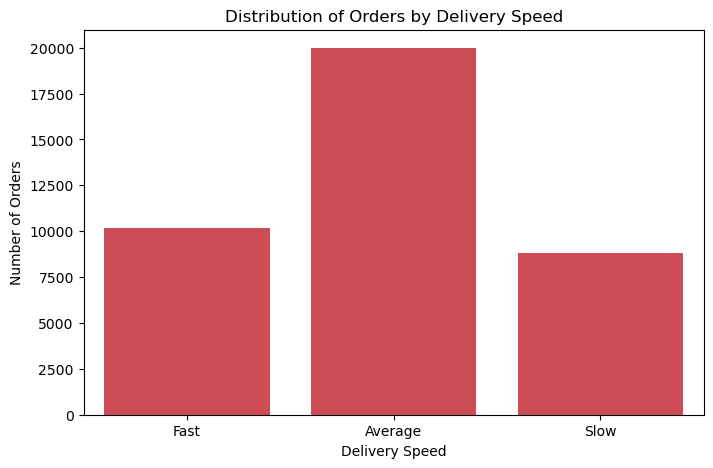

In [141]:
plt.figure(figsize=(8, 5))

speed_order = ['Fast', 'Average', 'Slow']

sns.countplot(
    data=df,
    x='delivery_speed',
    order=speed_order,
    color='#E23744'
)

plt.title('Distribution of Orders by Delivery Speed')
plt.xlabel('Delivery Speed')
plt.ylabel('Number of Orders')
plt.show()

> **Finding:** The majority of orders fall under the **Average** delivery-speed category, with **19,982 orders**, followed by **Fast** deliveries with **10,164 orders** and **Slow** deliveries with **8,818 orders**.

#### **3. How Is Delivery Time Associated with Road Traffic Density?**

The average delivery time is compared across different road traffic conditions to examine whether delivery duration varies with traffic levels.

In [142]:
traffic_delivery = df.groupby('Road_traffic_density')['Time_taken (min)'].mean().sort_values()
traffic_delivery

Road_traffic_density
Low       21.496461
Medium    26.925701
High      27.413489
Jam       31.440229
Name: Time_taken (min), dtype: float64

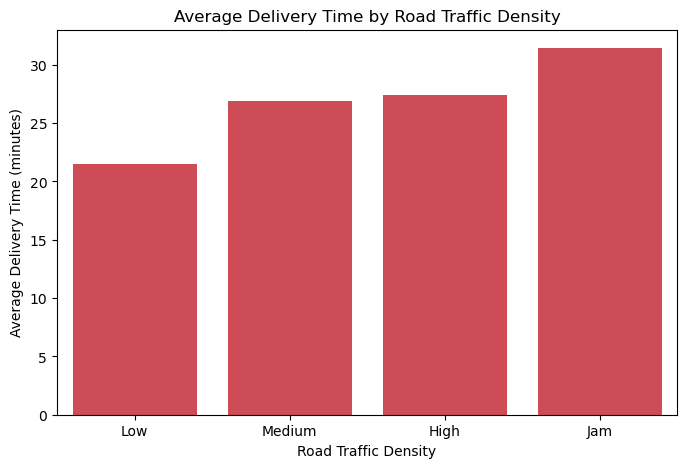

In [143]:
plt.figure(figsize=(8, 5))

traffic_order = ['Low', 'Medium', 'High', 'Jam']

sns.barplot(
    data=df,
    x='Road_traffic_density',
    y='Time_taken (min)',
    order=traffic_order,
    color='#E23744',
    errorbar=None
)

plt.title('Average Delivery Time by Road Traffic Density')
plt.xlabel('Road Traffic Density')
plt.ylabel('Average Delivery Time (minutes)')
plt.show()

> **Finding:** Average delivery time increases with road traffic density. Orders under **Low** traffic have the shortest average delivery time at **21.50 minutes**, while orders under **Jam** conditions have the highest at **31.44 minutes**. This shows a clear association between heavier traffic conditions and longer delivery times.

#### **4. How Does Delivery Time Vary Within Each Traffic Condition?**

The distribution of delivery time is compared across different road traffic conditions to examine variations and the spread of delivery times within each category.

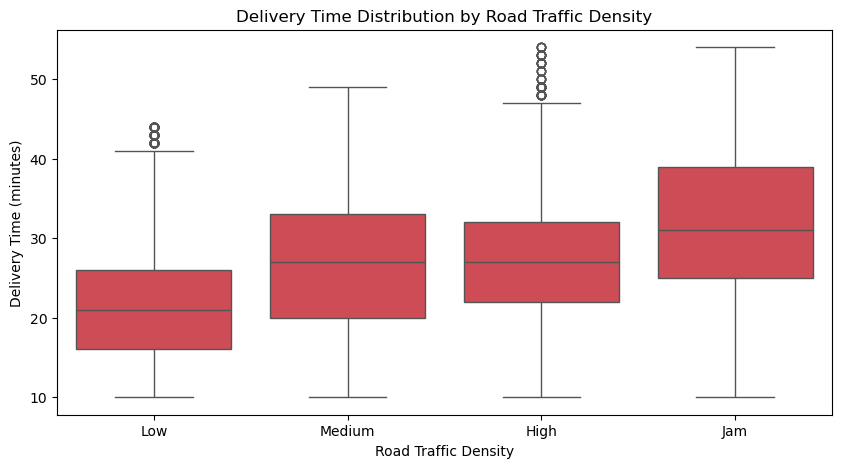

In [144]:
plt.figure(figsize=(10, 5))

traffic_order = ['Low', 'Medium', 'High', 'Jam']

sns.boxplot(
    data=df,
    x='Road_traffic_density',
    y='Time_taken (min)',
    order=traffic_order,
    color='#E23744'
)

plt.title('Delivery Time Distribution by Road Traffic Density')
plt.xlabel('Road Traffic Density')
plt.ylabel('Delivery Time (minutes)')
plt.show()

> **Finding:** Delivery times generally increase as road traffic becomes heavier. The median delivery time rises from **Low** traffic to **Jam** conditions, while **Jam** also shows a wider spread of delivery times. This indicates that heavier traffic is associated with both longer and more variable delivery times.

#### **5. How Is Delivery Time Associated with Weather Conditions?**

The average delivery time is compared across different weather conditions to examine whether delivery duration varies under different weather conditions.

In [145]:
weather_delivery = df.groupby('Weather_conditions')['Time_taken (min)'].mean().sort_values()
weather_delivery

Weather_conditions
Sunny         22.196669
Sandstorms    26.121590
Stormy        26.146835
Windy         26.388440
Cloudy        29.154655
Fog           29.220420
Name: Time_taken (min), dtype: float64

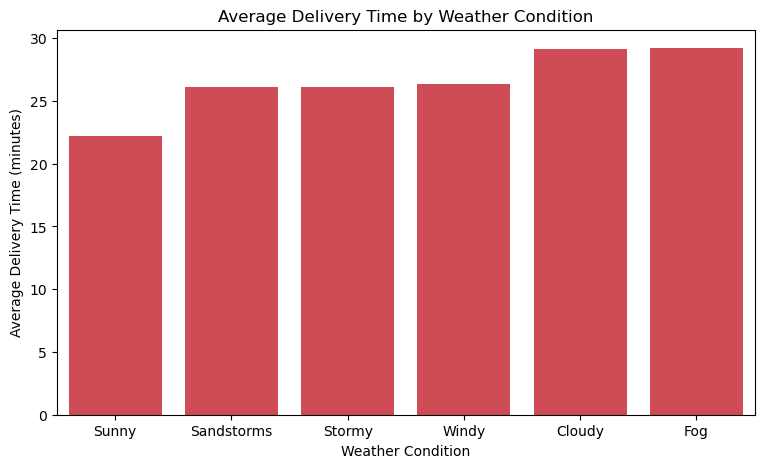

In [146]:
plt.figure(figsize=(9, 5))

weather_order = weather_delivery.index

sns.barplot(
    data=df,
    x='Weather_conditions',
    y='Time_taken (min)',
    order=weather_order,
    color='#E23744',
    errorbar=None
)

plt.title('Average Delivery Time by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Delivery Time (minutes)')
plt.show()

> **Finding:** Average delivery time varies across weather conditions. **Sunny** conditions have the lowest average delivery time at **22.20 minutes**, while **Fog** has the highest at **29.22 minutes**, closely followed by **Cloudy** conditions at **29.15 minutes**. This indicates that adverse or less favorable weather conditions are associated with longer delivery times.

#### **6. How Does Delivery Time Vary Within Each Weather Condition?**

The distribution of delivery time is compared across different weather conditions to examine the variation and spread of delivery times within each category.

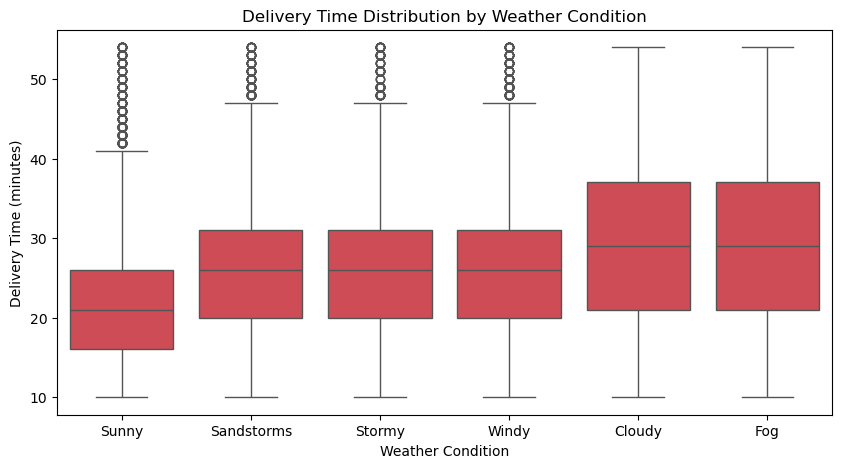

In [147]:
plt.figure(figsize=(10, 5))

weather_order = [
    'Sunny',
    'Sandstorms',
    'Stormy',
    'Windy',
    'Cloudy',
    'Fog'
]

sns.boxplot(
    data=df,
    x='Weather_conditions',
    y='Time_taken (min)',
    order=weather_order,
    color='#E23744'
)

plt.title('Delivery Time Distribution by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Delivery Time (minutes)')
plt.show()

> **Finding:** Delivery times vary across weather conditions, with **Sunny** conditions showing the lowest median delivery time. **Cloudy** and **Fog** conditions have the highest median delivery times and wider distributions, indicating greater variation in delivery duration. The other weather conditions show relatively similar median delivery times.

#### **7. How Is Delivery Time Associated with Type of Order?**

The average delivery time is compared across different order types to examine whether delivery duration varies by the type of food order.

In [148]:
order_delivery = df.groupby('Type_of_order')['Time_taken (min)'].mean().sort_values()
order_delivery

Type_of_order
Drinks    26.470926
Buffet    26.511222
Snack     26.580336
Meal      26.762226
Name: Time_taken (min), dtype: float64

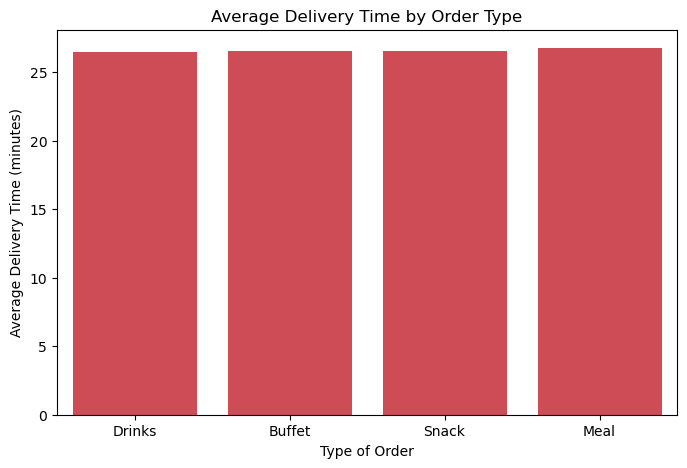

In [149]:
plt.figure(figsize=(8, 5))

order_order = ['Drinks', 'Buffet', 'Snack', 'Meal']

sns.barplot(
    data=df,
    x='Type_of_order',
    y='Time_taken (min)',
    order=order_order,
    color='#E23744',
    errorbar=None
)

plt.title('Average Delivery Time by Order Type')
plt.xlabel('Type of Order')
plt.ylabel('Average Delivery Time (minutes)')
plt.show()

> **Finding:** Average delivery times are very similar across all order types, ranging from **26.47 minutes for Drinks** to **26.76 minutes for Meal** orders. This suggests that **type of order shows only a small variation in average delivery time** in this dataset.

#### **8. How Are Different Order Types Distributed?**

The distribution of orders across different order types is examined to understand the composition of the dataset.

In [150]:
order_counts = df['Type_of_order'].value_counts()
order_counts

Type_of_order
Snack     9815
Meal      9774
Drinks    9751
Buffet    9624
Name: count, dtype: int64

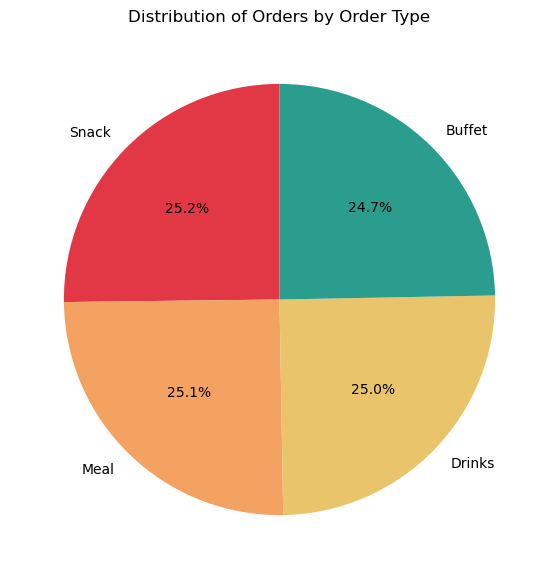

In [151]:
plt.figure(figsize=(7, 7))

colors = ['#E23744', '#F4A261', '#E9C46A', '#2A9D8F']

plt.pie(
    order_counts,
    labels=order_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Distribution of Orders by Order Type')
plt.show()

> **Finding:** The four order types are distributed almost evenly in the dataset. **Snack** orders account for the largest share with **9,815 orders**, while **Buffet** orders have the smallest share with **9,624 orders**. The relatively balanced distribution indicates that no single order type dominates the dataset.

#### **9. Is Delivery Distance Associated with Delivery Time?**

The relationship between delivery distance and delivery time is examined to determine whether longer delivery distances are associated with longer delivery durations.

In [152]:
distance_time_corr = df['distance_km'].corr(df['Time_taken (min)'])
distance_time_corr

np.float64(0.3215323518552995)

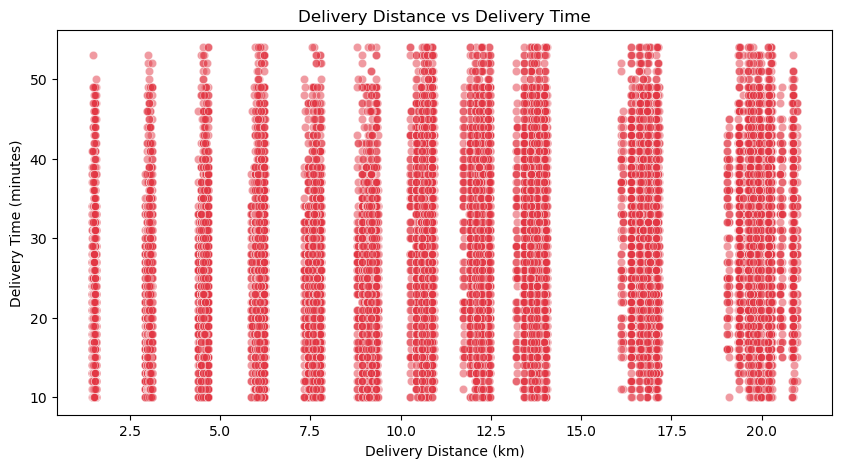

In [153]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='distance_km',
    y='Time_taken (min)',
    color='#E23744',
    alpha=0.5
)

plt.title('Delivery Distance vs Delivery Time')
plt.xlabel('Delivery Distance (km)')
plt.ylabel('Delivery Time (minutes)')
plt.show()

> **Finding:** Delivery distance has a **positive association** with delivery time, with a correlation coefficient of **0.322**. The scatter plot shows that delivery times tend to increase as distance increases, although there is considerable variation in delivery time at similar distances. This suggests that distance is associated with delivery time, but other factors also contribute to delivery duration.

#### **10. How Does Average Delivery Time Change Across Distance Ranges?**

Delivery distances are grouped into ranges to examine how average delivery time changes as the distance increases.

In [154]:
distance_bins = [0, 5, 10, 15, 20, float('inf')]
distance_labels = ['0–5 km', '5–10 km', '10–15 km', '15–20 km', '20+ km']

df['Distance_Range'] = pd.cut(
    df['distance_km'],
    bins=distance_bins,
    labels=distance_labels,
    right=False
)

In [155]:
distance_range_delivery = (
    df.groupby('Distance_Range', observed=False)['Time_taken (min)']
    .mean()
)

distance_range_delivery

Distance_Range
0–5 km      22.420308
5–10 km     24.639349
10–15 km    30.091511
15–20 km    30.074647
20+ km      30.083879
Name: Time_taken (min), dtype: float64

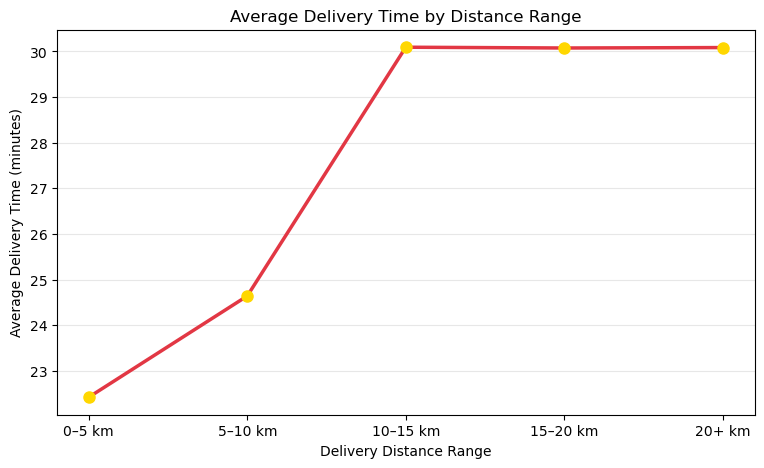

In [156]:
plt.figure(figsize=(9, 5))

plt.plot(
    distance_range_delivery.index,
    distance_range_delivery.values,
    marker='o',
    markersize=8,
    linewidth=2.5,
    color='#E23744',
    markerfacecolor='#FFD700',
    markeredgecolor='#FFD700'
)

plt.title('Average Delivery Time by Distance Range')
plt.xlabel('Delivery Distance Range')
plt.ylabel('Average Delivery Time (minutes)')
plt.grid(axis='y', alpha=0.3)

plt.show()

> **Finding:** Average delivery time increases from **22.42 minutes** for orders within 0–5 km to **30.09 minutes** for orders in the 10–15 km range. Beyond 10 km, the average delivery time remains relatively stable at around **30 minutes**, suggesting that the association between distance and delivery time is stronger at shorter distances and levels off for longer distances in this dataset.

#### **11. How Does Delivery Time Vary Across City Classifications?**

The distribution of delivery time is compared across different city classifications to examine whether delivery duration varies by delivery location.

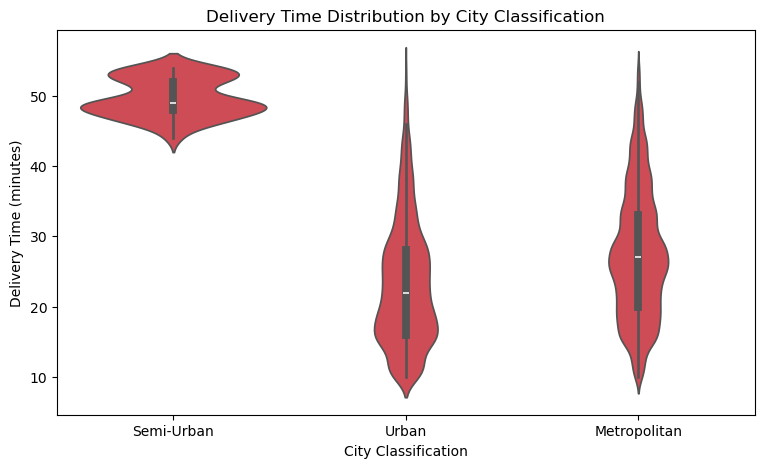

In [157]:
city_order = ['Semi-Urban', 'Urban', 'Metropolitan']

plt.figure(figsize=(9, 5))

sns.violinplot(
    data=df,
    x='City',
    y='Time_taken (min)',
    order=city_order,
    color='#E23744'
)

plt.title('Delivery Time Distribution by City Classification')
plt.xlabel('City Classification')
plt.ylabel('Delivery Time (minutes)')
plt.show()

> **Finding:** Delivery time varies across city classifications, with **Urban** orders showing the lowest average delivery time at **23.24 minutes**, followed by **Metropolitan** orders at **27.45 minutes**. Semi-Urban orders have a much higher average of **49.69 minutes**, but this category contains only **146 orders**, compared with 8,782 Urban and 30,036 Metropolitan orders. Therefore, the Semi-Urban result should be interpreted cautiously due to its small sample size.

#### **11(i). How Do Average Delivery Times and Order Counts Differ by City Classification?**

Average delivery time and order count are compared across city classifications to further examine variations in delivery time and validate the observed distribution.

In [158]:
city_summary = df.groupby('City')['Time_taken (min)'].agg(
    Average_Delivery_Time='mean',
    Order_Count='count'
).sort_values('Average_Delivery_Time')

city_summary

,Average_Delivery_Time,Order_Count
City,,
Urban,23.243339,8782
Metropolitan,27.445199,30036
Semi-Urban,49.691781,146


> **Finding:** The city-wise comparison confirms that **Urban** orders have the lowest average delivery time at **23.24 minutes**, while **Metropolitan** orders average **27.45 minutes**. Although **Semi-Urban** orders show a much higher average of **49.69 minutes**, there are only **146 Semi-Urban orders**, compared with 8,782 Urban and 30,036 Metropolitan orders. Therefore, the Semi-Urban result should be interpreted cautiously due to its small sample size.

#### **12. How Are Delivery Locations Distributed Geographically?**

The geographic distribution of delivery locations is examined using latitude and longitude coordinates to understand the spatial coverage of the food delivery orders.

In [159]:
fig = px.scatter(
    df,
    x='Delivery_location_longitude',
    y='Delivery_location_latitude',
    color='Time_taken (min)',
    title='Geographic Distribution of Delivery Locations',
    labels={
        'Delivery_location_longitude': 'Longitude',
        'Delivery_location_latitude': 'Latitude',
        'Time_taken (min)': 'Delivery Time (min)'
    },
    color_continuous_scale='Reds'
)

fig.show()

> **Finding:** The delivery locations are distributed across several distinct geographic clusters rather than being concentrated in a single area. Delivery times vary within these locations, with both shorter and longer delivery times appearing across different geographic areas. The visualization therefore shows that delivery time varies geographically, although no single clear spatial pattern can be established from the location distribution alone.

#### **13. How Does Average Delivery Time Vary Across Geographic Regions?**

The delivery area is divided into latitude and longitude regions to compare average delivery times across different geographic areas.

In [160]:
# creating geographic bands.

df['Latitude_Region'] = pd.cut(
    df['Delivery_location_latitude'],
    bins=5
)

df['Longitude_Region'] = pd.cut(
    df['Delivery_location_longitude'],
    bins=5
)

In [161]:
location_heatmap = df.pivot_table(
    values='Time_taken (min)',
    index='Latitude_Region',
    columns='Longitude_Region',
    aggfunc='mean',
    observed=False
)

location_heatmap

Longitude_Region,"(72.763, 75.936]","(75.936, 79.093]","(79.093, 82.25]","(82.25, 85.407]","(85.407, 88.563]"
Latitude_Region,,,,,
"(9.946, 14.185]",NaN,26.409704,26.714482,NaN,NaN
"(14.185, 18.402]",26.395948,26.608434,NaN,NaN,NaN
"(18.402, 22.619]",26.492945,NaN,NaN,NaN,25.019277
"(22.619, 26.837]",23.212978,28.226991,27.090589,25.12492,29.444867
"(26.837, 31.054]",26.655942,27.832415,NaN,NaN,NaN


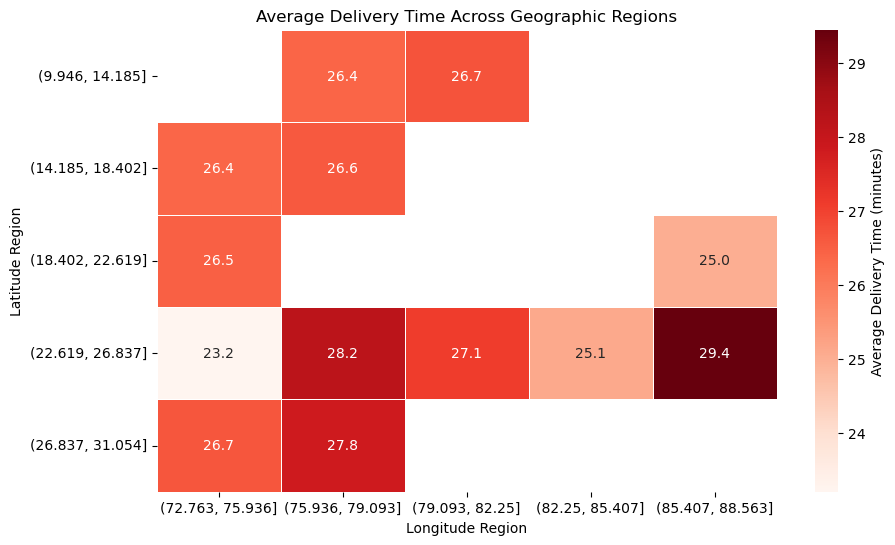

In [162]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    location_heatmap,
    annot=True,
    fmt='.1f',
    cmap='Reds',
    linewidths=0.5,
    cbar_kws={'label': 'Average Delivery Time (minutes)'}
)

plt.title('Average Delivery Time Across Geographic Regions')
plt.xlabel('Longitude Region')
plt.ylabel('Latitude Region')
plt.show()

> **Finding:** Average delivery time varies across the geographic regions represented in the dataset. The highest regional average is approximately **29.44 minutes**, while the lowest is approximately **23.21 minutes**. However, several geographic regions contain no observations, so the heatmap should be interpreted as a comparison of the areas represented in the dataset rather than a complete geographic coverage of all locations.

#### **14. Which Numerical Factors Are Most Closely Associated with Delivery Time?**

The correlations between delivery time and relevant numerical variables are examined to identify factors that show stronger or weaker associations with delivery duration.

In [163]:
correlation_data = df[
    [
        'distance_km',
        'multiple_deliveries',
        'Vehicle_condition',
        'Pickup_Hour',
        'Time_taken (min)'
    ]
].corr()

correlation_data

,distance_km,multiple_deliveries,Vehicle_condition,Pickup_Hour,Time_taken (min)
distance_km,1.000000,0.123174,0.008195,0.488539,0.321532
multiple_deliveries,0.123174,1.000000,-0.102991,0.073538,0.383138
Vehicle_condition,0.008195,-0.102991,1.000000,0.010778,-0.242171
Pickup_Hour,0.488539,0.073538,0.010778,1.000000,0.206507
Time_taken (min),0.321532,0.383138,-0.242171,0.206507,1.000000


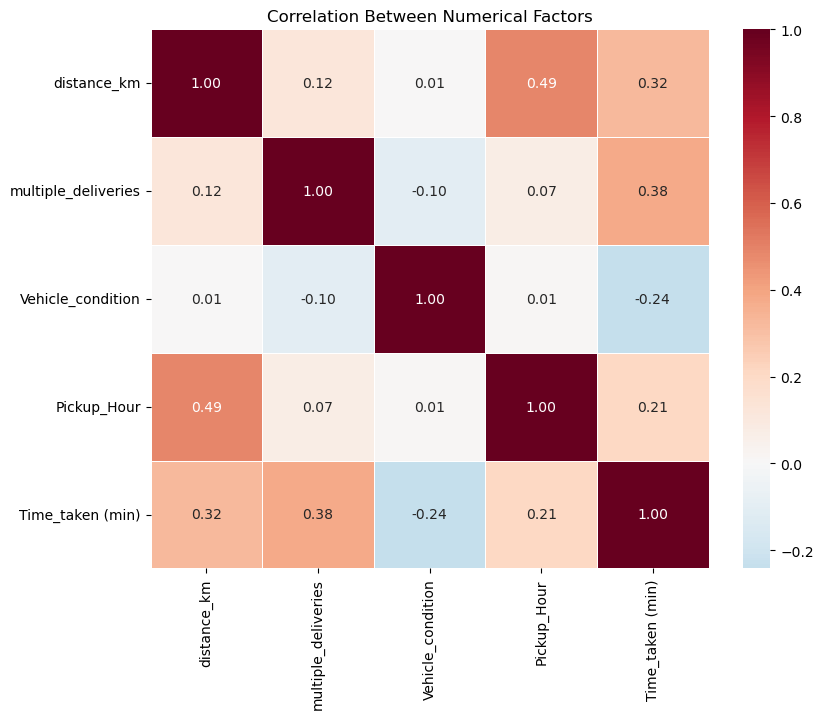

In [164]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_data,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Between Numerical Factors')
plt.show()

> **Finding:** Among the numerical variables examined, **multiple deliveries** shows the strongest positive association with delivery time (**0.383**), followed by **delivery distance** (**0.322**). **Vehicle condition** has a negative association with delivery time (**-0.242**), while **Pickup Hour** shows a weaker positive association (**0.207**). Overall, multiple deliveries and distance are the numerical factors most closely associated with delivery time in this analysis.

#### **15. How Does Delivery Time Vary with the Number of Multiple Deliveries?**

The average delivery time is examined across different numbers of simultaneous deliveries to understand how delivery duration varies with multiple deliveries.

In [165]:
multiple_delivery_time = (
    df.groupby('multiple_deliveries')['Time_taken (min)']
    .mean())

multiple_delivery_time

multiple_deliveries
0.0    23.155446
1.0    26.995952
2.0    40.489338
3.0    47.846645
Name: Time_taken (min), dtype: float64

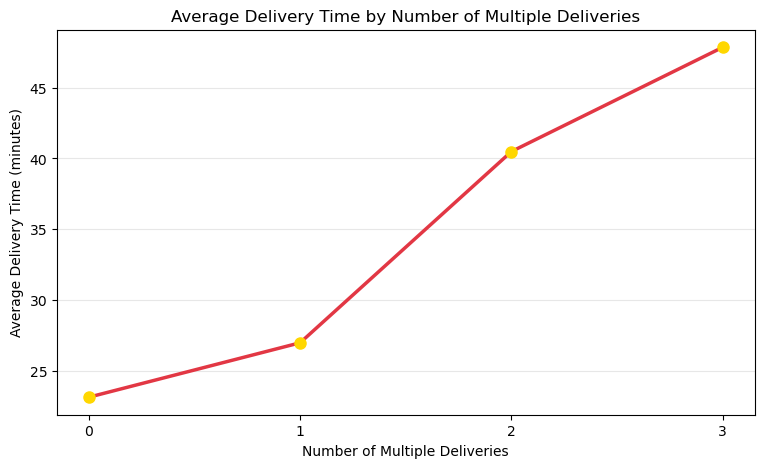

In [166]:
plt.figure(figsize=(9, 5))

plt.plot(
    multiple_delivery_time.index,
    multiple_delivery_time.values,
    marker='o',
    markersize=8,
    linewidth=2.5,
    color='#E23744',
    markerfacecolor='#FFD700',
    markeredgecolor='#FFD700'
)

plt.title('Average Delivery Time by Number of Multiple Deliveries')
plt.xlabel('Number of Multiple Deliveries')
plt.ylabel('Average Delivery Time (minutes)')
plt.xticks([0, 1, 2, 3])
plt.grid(axis='y', alpha=0.3)

plt.show()

> **Finding:** Average delivery time increases substantially as the number of simultaneous deliveries increases. Orders with **no multiple deliveries** have an average delivery time of **23.16 minutes**, compared with **27.00 minutes** for one additional delivery, **40.49 minutes** for two, and **47.85 minutes** for three. This makes `multiple_deliveries` the numerical factor with the strongest positive association with delivery time among the variables examined.

#### **16. How Are Orders Distributed Across Distance Ranges?**

The number of orders in each delivery-distance range is examined to understand how the dataset is distributed across different distance categories.

In [167]:
distance_range_counts = df['Distance_Range'].value_counts().sort_index()

distance_range_counts

Distance_Range
0–5 km      10390
5–10 km     10445
10–15 km    10567
15–20 km     5881
20+ km       1681
Name: count, dtype: int64

> **Finding:** Most distance ranges contain a similar number of orders, with approximately **10,000 orders each** in the 0–5 km, 5–10 km, and 10–15 km ranges. The 15–20 km range contains **5,881 orders**, while the 20+ km range has **1,681 orders**. The distance-based analysis is therefore well represented across the shorter and medium-distance ranges, while the 20+ km category has a smaller sample.

#### **17. How Does Delivery Time Vary with Traffic and Multiple Deliveries?**

The combined relationship between road traffic density and the number of multiple deliveries is examined to understand how these operational factors are associated with delivery time.

In [168]:
traffic_multiple = df.pivot_table(
    values='Time_taken (min)',
    index='Road_traffic_density',
    columns='multiple_deliveries',
    aggfunc='mean'
)

traffic_multiple

multiple_deliveries,0.0,1.0,2.0,3.0
Road_traffic_density,,,,
High,24.151460,27.785659,39.773006,47.600000
Jam,27.789425,31.095479,41.533397,48.255319
Low,19.419751,22.434908,38.641509,43.500000
Medium,24.027244,27.333654,38.830097,46.227273


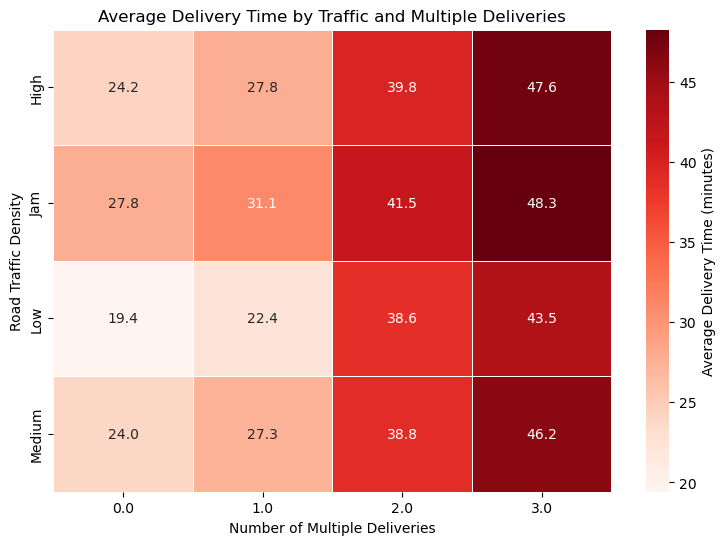

In [169]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    traffic_multiple,
    annot=True,
    fmt='.1f',
    cmap='Reds',
    linewidths=0.5,
    cbar_kws={'label': 'Average Delivery Time (minutes)'}
)

plt.title('Average Delivery Time by Traffic and Multiple Deliveries')
plt.xlabel('Number of Multiple Deliveries')
plt.ylabel('Road Traffic Density')
plt.show()

> **Finding:** Delivery time increases as the number of multiple deliveries increases across all traffic conditions. The increase is particularly noticeable when there are **2 or 3 multiple deliveries**, with average delivery times exceeding **38 minutes** in every traffic category. Traffic also shows an additional association with delivery time, with **Jam** conditions generally recording higher averages than lower traffic conditions. Overall, the combination of heavier traffic and multiple deliveries is associated with longer delivery times.